In [20]:
import gymnasium as gym
import gymnasium_jsbsim  # noqa: F401
from stable_baselines3 import DDPG
from stable_baselines3.common.vec_env import SubprocVecEnv

In [ ]:
def make_env(i):
    def _init():
        # for each subprocess
        import gymnasium_jsbsim
        # create an environment
        env = gym.make("JSBSim-HeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0")
        # create a fixed seed env
        # initial Heading Control Task ignores seed and sets the observation env
        # TODO create a new task that incorporates seed and optionally normalizes observation space
        obs, info = env.reset(seed=42+i)
        print(obs)
        return env
    return _init
envs = SubprocVecEnv([make_env(i) for i in range(5)])



     JSBSim Flight Dynamics Model v1.2.4 Feb  7 2026 11:12:49
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

[ 5.00000000e+03  1.21430643e-17  1.50920942e-16  2.02536000e+02
  4.44089210e-15 -5.32907052e-15  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -3.72529030e-09  1.25629209e-15  0.00000000e+00
  2.99000000e+02]


     JSBSim Flight Dynamics Model v1.2.4 Feb  7 2026 11:12:49
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

[ 5.00000000e+03  1.21430643e-17  1.50920942e-16  2.02536000e+02
  4.44089210e-15 -5.32907052e-15  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -3.72529030e-09  1.25629209e-15  0.00000000e+00
  2.99000000e+02]


     JSBSim Flight Dynamics Model v1.2.4 Feb  7 2026 11:12:49
            [JSBSim-ML v2.0]

JSBSim startup beginning ...

[ 5.00000000e+03  1.21430643e-17  1.50920942e-16  2.02536000e+02
  4.440

In [ ]:
# train the model
model = DDPG("MlpPolicy", envs, verbose=1, tensorboard_log="../logs/ddpg", seed=42, device='cuda')
model.learn(total_timesteps=100_000, log_interval=10)
model.save("../models/ddpg_no_tuning_100_000")

Using cuda device
Logging to ../logs/ddpg/DDPG_1
---------------------------------
| time/              |          |
|    episodes        | 10       |
|    fps             | 1699     |
|    time_elapsed    | 0        |
|    total_timesteps | 800      |
| train/             |          |
|    actor_loss      | -116     |
|    critic_loss     | 36.2     |
|    learning_rate   | 0.001    |
|    n_updates       | 139      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 20       |
|    fps             | 1609     |
|    time_elapsed    | 0        |
|    total_timesteps | 1410     |
| train/             |          |
|    actor_loss      | -111     |
|    critic_loss     | 6        |
|    learning_rate   | 0.001    |
|    n_updates       | 261      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 30       |
|    fps             | 1592     |

/tmp/ipykernel_10136/2481496732.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


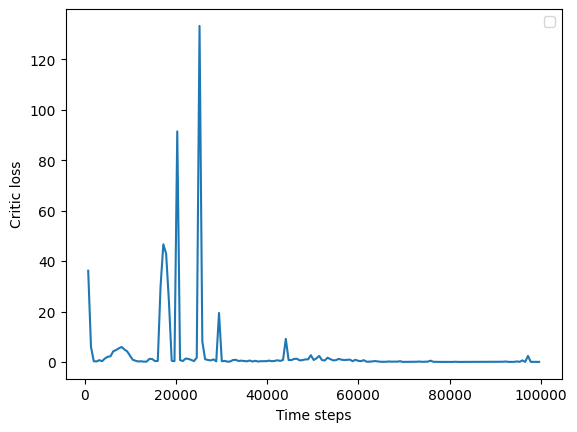

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../graphs/DDPG_1_critic.csv")
plt.plot(df['Step'], df['Value'])
plt.ylabel('Critic loss')
plt.xlabel('Time steps')
plt.legend()
plt.show()

/tmp/ipykernel_10136/3966679489.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


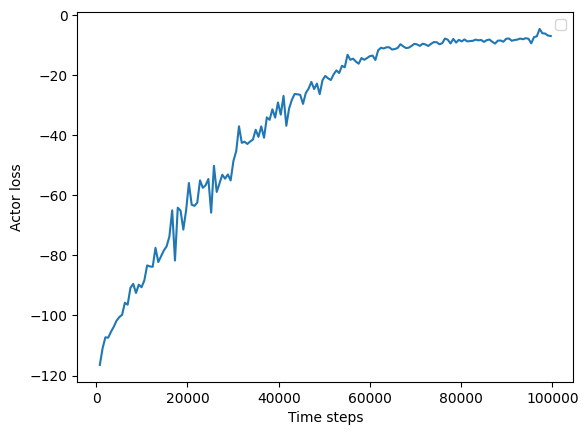

In [31]:
df = pd.read_csv("../graphs/DDPG_1_actor.csv")
plt.plot(df['Step'], df['Value'])
plt.ylabel('Actor loss')
plt.xlabel('Time steps')
plt.legend()
plt.show()

In [34]:
# tune the learning rate
for i in [3e-7, 1e-7, 3e-6, 1e-6, 3e-5, 1e-4, 3e-4, 1e-3]:
    model = DDPG("MlpPolicy", envs, verbose=1, tensorboard_log="../logs/ddpg", seed=42, device='cuda', learning_rate=i)
    model.learn(total_timesteps=100_000, log_interval=10)
    model.save(f"../models/ddpg_tuning_lr{i}_100_000")

Using cuda device
Logging to ../logs/ddpg/DDPG_2
---------------------------------
| time/              |          |
|    episodes        | 10       |
|    fps             | 1618     |
|    time_elapsed    | 0        |
|    total_timesteps | 800      |
| train/             |          |
|    actor_loss      | -132     |
|    critic_loss     | 122      |
|    learning_rate   | 3e-07    |
|    n_updates       | 139      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 20       |
|    fps             | 1596     |
|    time_elapsed    | 0        |
|    total_timesteps | 1410     |
| train/             |          |
|    actor_loss      | -127     |
|    critic_loss     | 173      |
|    learning_rate   | 3e-07    |
|    n_updates       | 261      |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 30       |
|    fps             | 1516     |

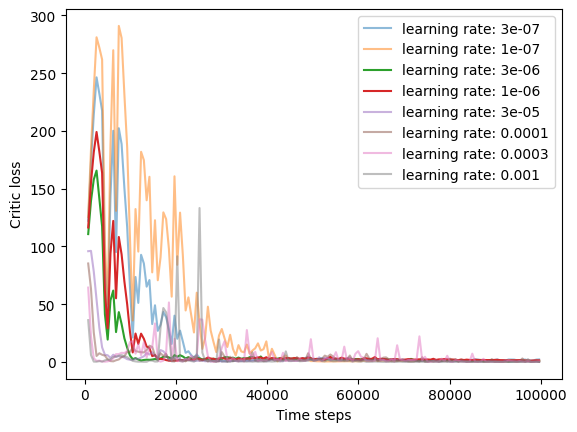

In [39]:
i = 2
for lr in [3e-7, 1e-7, 3e-6, 1e-6, 3e-5, 1e-4, 3e-4, 1e-3]:
    df = pd.read_csv(f"../graphs/DDPG_{i}_critic.csv")
    if i == 4 or i == 5:
        a = 1.0
    else:
        a = 0.5
    plt.plot(df['Step'], df['Value'], label=f"learning rate: {lr}", alpha=a)
    i+=1
plt.ylabel('Critic loss')
plt.xlabel('Time steps')
plt.legend()
plt.show()